# Safety, Oscillations, Liveness and Fairness in Qunatitative Argumentation Dialogues.

This notebook demonstrates an example from an ongoing work on Safety, Oscillations, Liveness and Fairness (SOLF) notions in Qunatitative Argumentation Dialogues.
Intuitively, the SOLF notions are concerned with various aspects of credibility analysis of a so-called topic set under evolutions of QBAF dialgoues.

At the formal level, we consider QBAF expansions in which new arguments are added throughout the dialogue.
An argument is deemed credible if its final strength exceeds a credibility threshold.
Under this setting, the SOLF notions captures the behaviour of the topic set across a certain credibility threshold.

This example notebook is based upon the SOLF implementation available at https://github.com/TimKam/Quantitative-Bipolar-Argumentation


### Example Setup

For this example, we consider the simple case of three QBAF dialogue, given as $Q, Q_1, Q_2$ below.
The QBAF Q, also referred to as the initial QBAF, consists of three arguments. 
In QBAF $Q_1$ (the first update) the initial QBAF is appended by an argument, and a similar situation happens in $Q_2$ (the second update).

We fix the semantics to be Discontinuity-Free Quantitative Argumentation Debate model, or DFQuAD model for short.

In [14]:
from qbaf import QBAFramework
from qbaf_solf.safety_oscillations_liveness import *
from qbaf_solf.fairness_notions import *
from qbaf_visualizer.Visualizer import *

args = ['a', 'b', 'c']
args_1 = ['a', 'b', 'c', 'd']
args_2 = ['a', 'b', 'c', 'd', 'e']

supp = [('c', 'a')]
supp_1 = [('c', 'a')]
supp_2 = [('c', 'a')]

att = []
att_1 = [('d', 'a'), ('d', 'b')]
att_2 = [('d', 'a'), ('d', 'b'), ('e', 'd')]

Q = QBAFramework(args, [0.5, 0.7, 0.2], att, supp, semantics="DFQuAD_model")
Q_1 = QBAFramework(args_1, [0.5, 0.7, 0.2, 1.0], att_1, supp_1, semantics="DFQuAD_model")
Q_2 = QBAFramework(args_2, [0.5, 0.7, 0.2, 1.0, 0.8], att_2, supp_2, semantics="DFQuAD_model")

The QBAFs can be visualized as follows.

Initial QBAF:


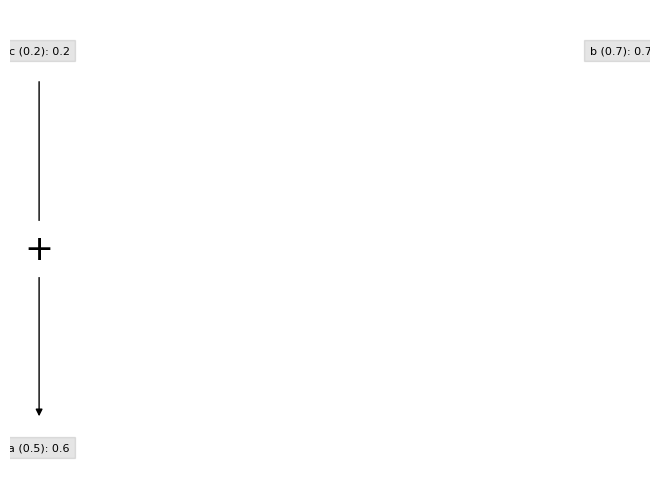

In [ ]:
print("Initial QBAF:")
visualize(Q, with_fs=True, round_to=6)

QBAF Expansion 1:


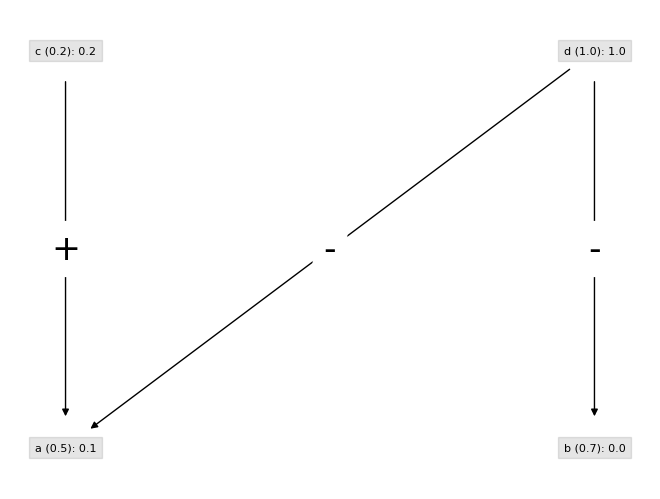

In [ ]:
print("QBAF Expansion 1:")
visualize(Q_1, with_fs=True, round_to=6)

QBAF Expansion 2:


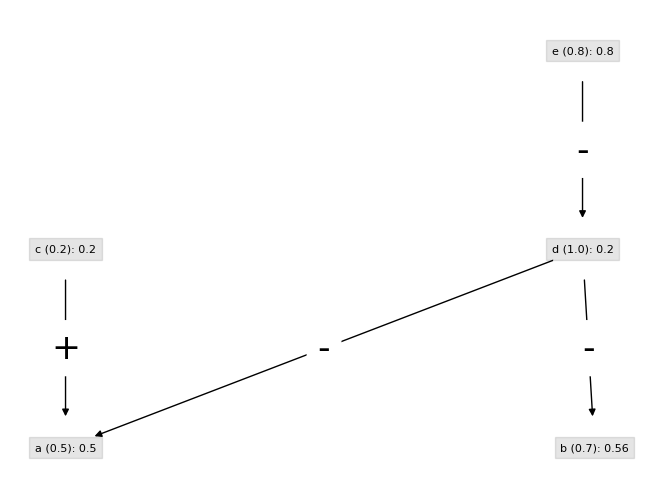

In [ ]:
print("QBAF Expansion 2:")
visualize(Q_2, with_fs=True, round_to=6)

Throughout this example, we vary the credibility threshold to demonstrate how our SOLF notions are behave w.r.t. it.  

### Safety

The notion of safety captures the intutition that bad things don't happen (over the course of the dialogue), i.e. , safety assesses whether the topic set maintains credibility at every point of the dialogue.

In addition to the arguments added throughout the dialogue, and the semantics,  the notion depends on the credibility threshold.
The plot below highlights how the safety of the topic set $\{a, c\}$ is
constrained by the choice of the threshold. 

Along the y-axis, we have the the binary classification of Safe or Not Safe over the chosen threshold; the chosen threshold is given along the x-axis.

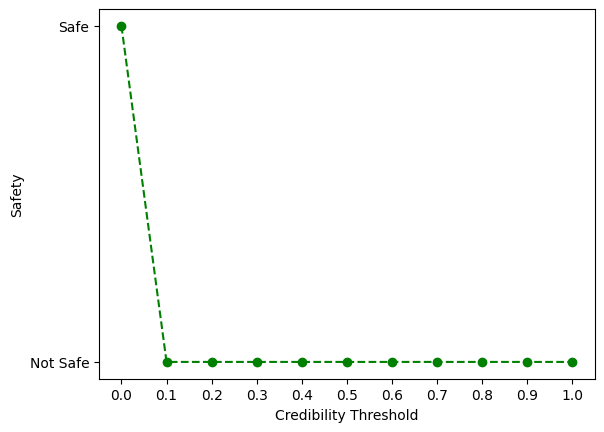

In [ ]:
from qbaf import QBAFramework
from qbaf_solf.safety_oscillations_liveness import *
import numpy as np
import matplotlib.pyplot as plt

x_axis = [x/10 for x in range(0, 11)]
safety_data = [int(is_safe([Q, Q_1, Q_2], ['a', 'c'], i)) for i in x_axis]

plt.yticks([0,1], ['Not Safe', 'Safe'])
plt.xticks(x_axis, [x/10 for x in range(0, 11)])
plt.xlabel('Credibility Threshold')
plt.ylabel('Safety')
plt.plot(x_axis, safety_data, 'go--')
plt.show()


Note that the topic set graph is 'montone', i.e., if the topic set is not safe w.r.t. a threshold, then it is also not safe w.r.t. any realtively higher threshold.

### Liveness

The notion of liveness captures the intutition that good things eventually happen (over the course of the dialogue), i.e. , liveness stipulates whether the topic set eventually attains credibility at the very end of the dialogue.

Analogous to safety, liveness is dependent on the credibility of the threshold.
The case for the threshold is demonstrated below---the plot highlights whether the topic set $\{a, c\}$ is live, given along the y-axis, over the chosen threshold, given along the x-axis.

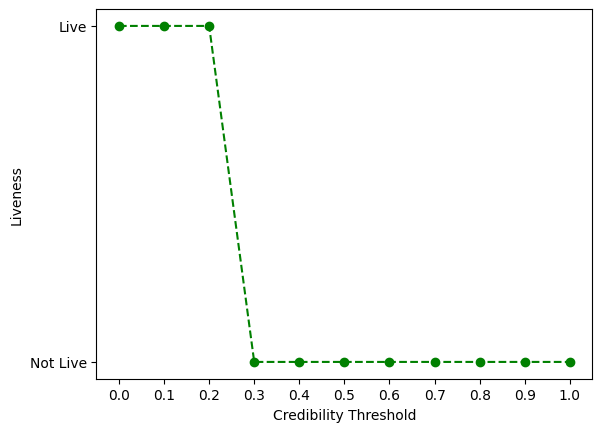

In [ ]:
x_axis = [x/10 for x in range(0, 11)]
liveness_data = [int(is_live([Q, Q_1, Q_2], ['a', 'c'], i)) for i in x_axis]


plt.yticks([0,1], ['Not Live', 'Live'])
plt.xticks(x_axis, [x/10 for x in range(0, 11)])
plt.xlabel('Credibility Threshold')
plt.ylabel('Liveness')
plt.plot(x_axis, liveness_data, 'go--')
plt.show()


Again, note that liveness is monotone w.r.t. the credibility threshold.

### Oscillations

The notions of safety and liveness concerns the behavior of the topic set above the credibility threshold.
However, such analysis doesn't provide an appropiate accessment of initially non-credible arguments.
Towards that, the notion of oscillation measures the flip-flopping behavior of the topic set across the threshold---arguments with lower oscillations across the threshold are relatively stable.

The bar graph below demonstrates the oscillation of the topic set $\{a, b, c\}$ across the threshold of 0.51.

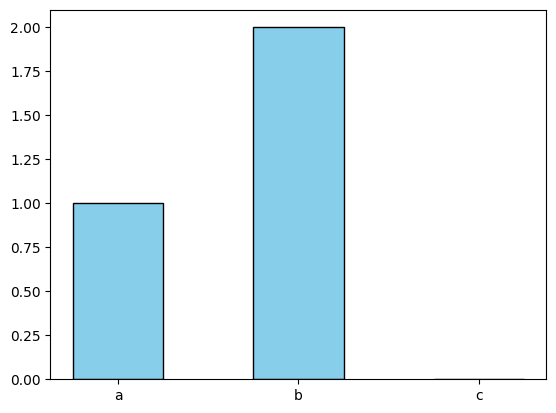

In [18]:
osciallation_data = number_of_oscillations([Q, Q_1, Q_2], ['a', 'b', 'c'], 0.51).items()

x_axis = [x[0] for x in osciallation_data]
y_axis = [x[1] for x in osciallation_data]

plt.bar(x_axis,
        y_axis,
        edgecolor = 'black',
        width = 0.5,
        color = 'skyblue')

plt.show()

### Fairness

Two classes of fairness notions are considered: discrete and gradual.
The discrete notions are concerned with how the behaviour of a single topic argument is realted to the behaviour of the whole set. Three such notions are introduced, namely ideally fair, lively fair and cautiously fair.

### Ideal Fairness

The notion of ideal fairness stipulates that the safety of a singular topic argument can be uplifted to the safety of the topic set.
In other words, if one particular topic argument is safe, then so is the whole topic set.

Given below is the ideal safety of the topic set $\{a, b, c\}$ w.r.t. the threshold 0.51.

In [19]:
print(is_ideal_fair([Q, Q_1, Q_2], ['a', 'b', 'c'], 0.51))


True


However, unlike safety, fairness is non-monotonic. The graph below illustrates the ideal fairness of the topic set $\{a, b, c\}$ as the threshold is increased from 0.0 to 1.0.

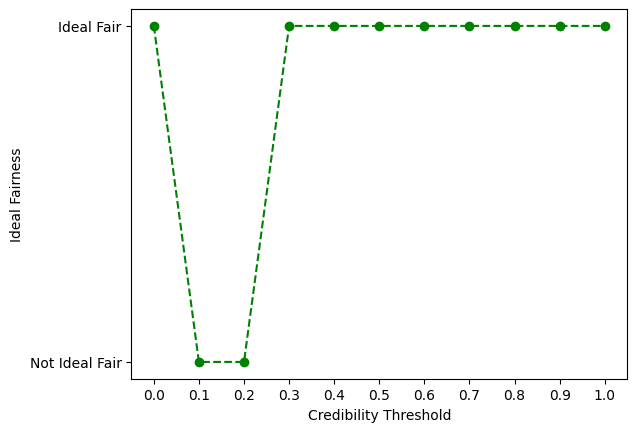

In [24]:
ideal_fairness_data = [is_ideal_fair([Q, Q_1, Q_2], ['a', 'b', 'c'], i/10) for i in range(0, 11)]

x_axis = [i/10 for i in range(0, 11)]

plt.yticks([0,1], ['Not Ideal Fair', 'Ideal Fair'])
plt.xticks(x_axis, [x/10 for x in range(0, 11)])
plt.xlabel('Credibility Threshold')
plt.ylabel('Ideal Fairness')
plt.plot(x_axis, [int(x) for x in ideal_fairness_data], 'go--')
plt.show()

### Live Fairness

Live Fairness stipulates that the liveness of one argument can be uplifted to be the liveness of the whole set.
In other words, if one particular topic argument is live, then so is the whole topic set.

We check the live fairness of the topic set $\{a,b,c\}$ w.r.t. the threshold 0.51.

In [21]:
print(is_ideal_fair([Q, Q_1, Q_2], ['a', 'b', 'c'], 0.51))

True


Again, live fairness is a non-monotonic notion, as demonstrated by the graph below.
The graph below sketches the live fairness of the topic set $\{a, b, c\}$ as the threshold is increased from 0.0 to 1.0.

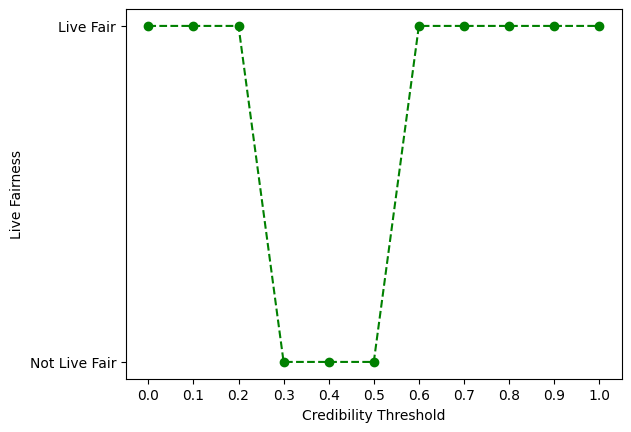

In [22]:
live_fairness_data = [is_live_fair([Q, Q_1, Q_2], ['a', 'b', 'c'], i/10) for i in range(0, 11)]

x_axis = [i/10 for i in range(0, 11)]

plt.yticks([0,1], ['Not Live Fair', 'Live Fair'])
plt.xticks(x_axis, [x/10 for x in range(0, 11)])
plt.xlabel('Credibility Threshold')
plt.ylabel('Live Fairness')
plt.plot(x_axis,[int(x) for x in live_fairness_data], 'go--')
plt.show()

### Cautious Fairness

Cautious Fairness is a weakening of ideal fairness.  According to this notion, the safety of one argument can be uplifted to the liveness of the whole set.
In other words, if one particular topic argument is safe, then the whole topic set is live.

We check the catious fairness of the topic set $\{a,b,c\}$ w.r.t. the threshold 0.51.

In [25]:
print(is_cautious_fair([Q, Q_1, Q_2], ['a', 'b', 'c'], 0.51))

True


In our example, the topic set $\{a,b,c\}$ is always cautiously fair, as shown by the plot below.

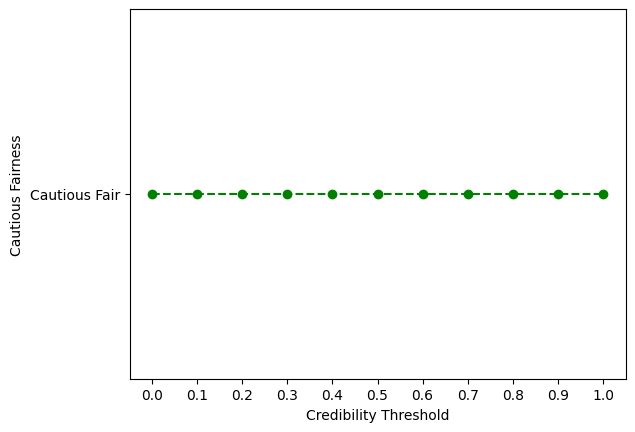

In [27]:
cautious_fairness_data = [is_cautious_fair([Q, Q_1, Q_2], ['a', 'b', 'c'], i/10) for i in range(0, 11)]

x_axis = [i/10 for i in range(0, 11)]

plt.yticks([0,1], ['Not Cautious Fair', 'Cautious Fair'])
plt.xticks(x_axis, [x/10 for x in range(0, 11)])
plt.xlabel('Credibility Threshold')
plt.ylabel('Cautious Fairness')
plt.plot(x_axis,[int(x) for x in cautious_fairness_data], 'go--')
plt.show()

Towards gradual fairness, we measure how evenly the credibility of a topic set is spread across the whole set. Two such measures are introduced, namely Gini based fairness and Shannon based fairness.

### Gini fairness

Gini fairness is inspired from the Gini index, studied in macroeconomic theory to study income-inequality.
Our reading of Gini fairness is adapted as a similarity measure between the credbility instances of the topic arguments against a counterfactual scenario.

In the example below, we calculate the Gini fairness for the threshold 0.51, against the topic set $\{a, b, c\}$.

In [17]:
print(calculate_gini_fairness([Q, Q_1, Q_2], ['a', 'b', 'c'], 0.51))

0.7615941559557646


We plot the fairness line and the safety curve for the threshold 0.51.
Fairness line is a linear function joining (0,0) to (n, k), where $n$ is the cardinality of the topic set and $k$ is the total instances, during the course of the dialogue, where at-least one of the topic arguments was credible.
The safety curve is defined piecewise as an aggregation of the instances of each topic argument's credible instances. 

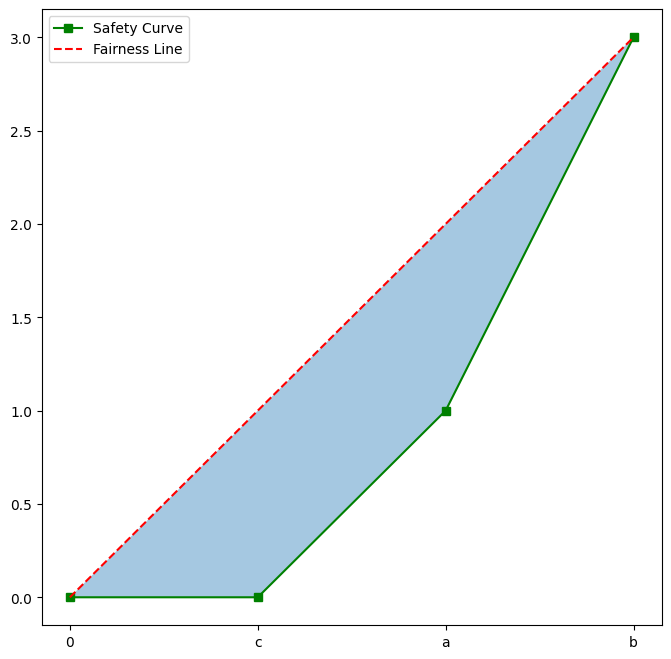

In [59]:
x_axis = [x for x in range(0, 4)]

# Calculating the safety curve
sorted_oscillations = sorted(number_of_oscillations([Q, Q_1, Q_2], ['a', 'b', 'c'], 0.51).items(), key=lambda item: item[1])
safety_curve = [0]
for x in sorted_oscillations:
    safety_curve.append(safety_curve[-1] + int(x[1]))

# Calculating the fairness line
fairness_line = np.linspace(0, safety_curve[-1], 4)


# Plotting the safety curve and fairness line
plt.figure(figsize=(8, 8))
plt.xticks(x_axis, ['0']+[x[0] for x in sorted_oscillations])
plt.plot(x_axis, safety_curve, label = 'Safety Curve', color='green', marker = 's')
plt.plot(x_axis, fairness_line, label = 'Fairness Line', linestyle = 'dashed', color='red')
plt.fill_between(x_axis, safety_curve, fairness_line, alpha=0.4)
plt.legend()
plt.show()


Given below is the Gini score of the topic set $\{a,b,c\}$ as the threshold is varied from 0.0 to 1.0.

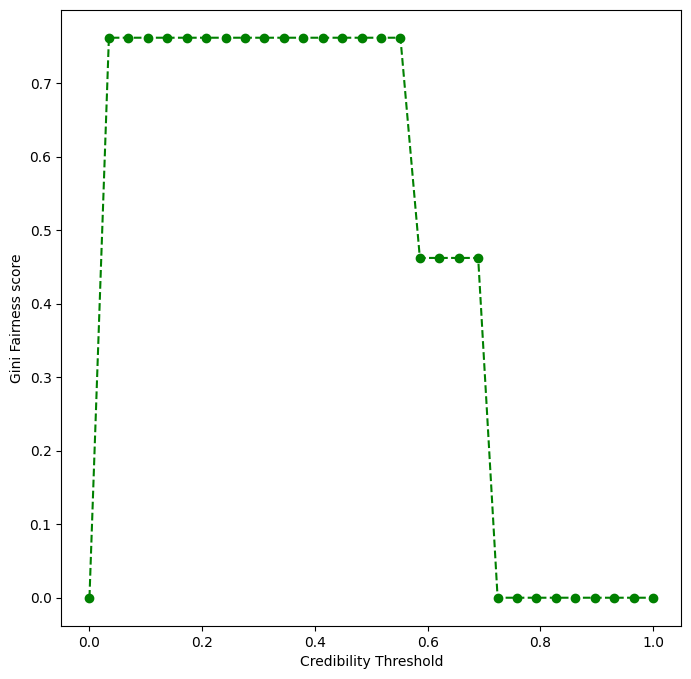

In [ ]:
x_axis = np.linspace(0.0, 1.0, 30)

y_axis = [calculate_gini_fairness([Q, Q_1, Q_2], ['a', 'b', 'c'], x) for x in x_axis]

plt.figure(figsize=(8, 8))
plt.xlabel('Credibility Threshold')
plt.ylabel('Gini Fairness score')
plt.plot(x_axis, y_axis, 'go--')

plt.show()

Note that in cases where the ideal and the situation at hand conincides, for example at the threshold of 0.0, Gini fairness returns the score of 0.  

### Shannon Fairness

Shannon fairness is inspired from the notion of Shannon entropy, as studied in information theory.
In our interpretation, Shannon based fairness measures the expectation of a threshold exceeding behaviour over the topic set.

Given below is the Shannon fairness score of the topic set $\{a, b, c\}$ w.r.t. the threshold 0.51.

In [58]:
print(calculate_shannon_fairness([Q, Q_1, Q_2], ['a', 'b', 'c'], 0.51))

0.579380164285695


The bar-graph of the probability measure for the calculation of Shannon based fairness is shown below.
The probability is measured in terms of the "surprise factor", i.e., how surpising it is for a topic argument to be credible.   

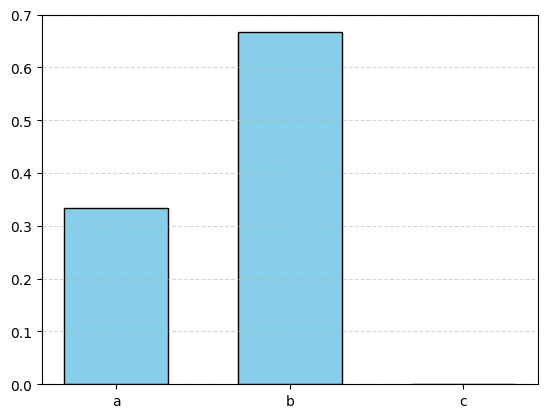

In [54]:
oscillations = number_of_oscillations([Q, Q_1, Q_2], ['a', 'b', 'c'], 0.51)
sum_of_oscillations = sum([x[1] for x in oscillations.items()])
oscillation_probability = [(x, oscillations[x]/sum_of_oscillations) for x in oscillations.keys()]

topic_set = [x[0] for x in oscillation_probability]
prob_of_surprise = [x[1] for x in oscillation_probability]

bars = plt.bar(topic_set,
              prob_of_surprise,
              color="skyblue",
              edgecolor="black",
              width=0.6)



plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

We also plot the behaviour of the Shannon based fairness as the threshold is varied from 0.0 to 1.0.

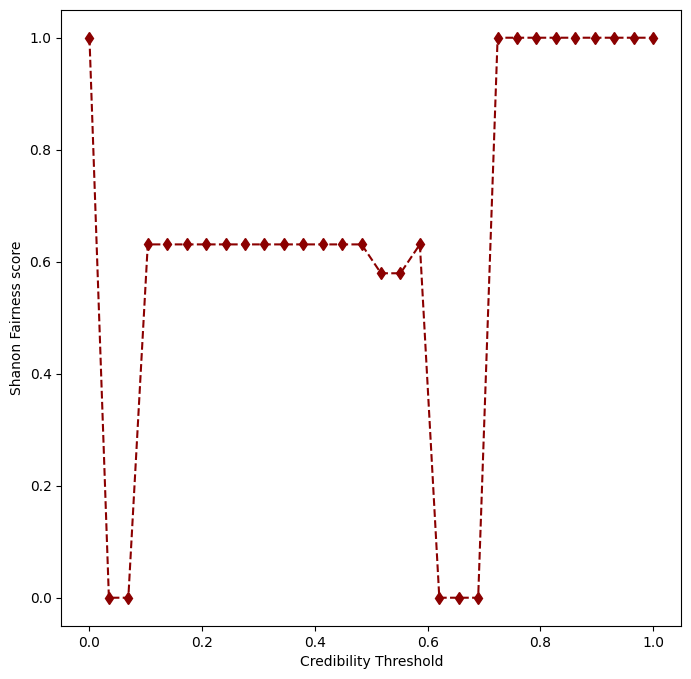

In [18]:
x_axis = np.linspace(0.0, 1.0, 30)

y_axis_shannon = [calculate_shannon_fairness([Q, Q_1, Q_2], ['a', 'b', 'c'], x) for x in x_axis]

plt.figure(figsize=(8, 8))
plt.xlabel('Credibility Threshold')
plt.ylabel('Shanon Fairness score')
plt.plot(x_axis, y_axis_shannon, c='darkred', linestyle='dashed', marker='d')
plt.show()

Note that in contrast to the case of Gini based fairness, perfect fairness scenarios have the score of 1 when Shannon fairness is considered.

Finally, we show the differnece between the two fairness measures in the graph below.
The graph illustrates the behaviour of the shannon fairness score vs the gini fairness scores as the threshold is varied from 0.0 to 1.0.

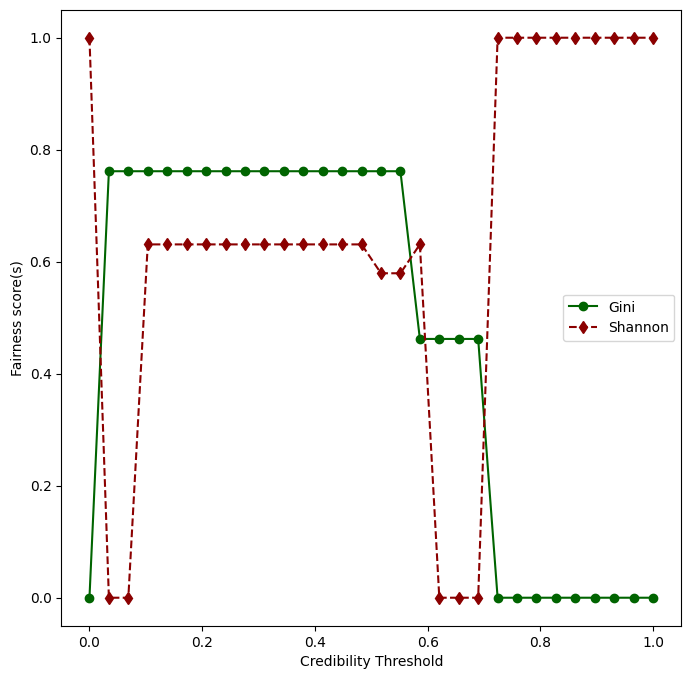

In [57]:
x_axis = np.linspace(0.0, 1.0, 30)

y_axis_gini = [calculate_gini_fairness([Q, Q_1, Q_2], ['a', 'b', 'c'], x) for x in x_axis]

y_axis_shannon = [calculate_shannon_fairness([Q, Q_1, Q_2], ['a', 'b', 'c'], x) for x in x_axis]

plt.figure(figsize=(8, 8))
plt.xlabel('Credibility Threshold')
plt.ylabel('Fairness score(s)')
plt.plot(x_axis, y_axis_gini, c='darkgreen', marker= 'o')
plt.plot(x_axis, y_axis_shannon, c='darkred', linestyle='dashed', marker='d')
plt.legend(['Gini', 'Shannon'])

plt.show()